# Classifiers
### Imports

In [26]:
# io import
import pickle
# processing data
import re
import nltk
import pandas as pd
import numpy as py
import seaborn as sns
import matplotlib.pyplot as plt
import stanza
stnz = stanza.Pipeline('en', download_method=None)
import dask
from dask.distributed import Client, LocalCluster
client = Client(processes=True, n_workers=4, threads_per_worker=20)
from bs4 import BeautifulSoup as beau
# sklearn
from sklearn.metrics import accuracy_score as acc_score
from sklearn.metrics import confusion_matrix as cfm
from sklearn.neighbors import KNeighborsClassifier as knc
from sklearn.naive_bayes import MultinomialNB as mnb
from sklearn.model_selection import train_test_split as tts
from sklearn.feature_extraction.text import TfidfVectorizer as tfv

2025-04-18 11:25:43 INFO: Loading these models for language: en (English):
| Processor    | Package                   |
--------------------------------------------
| tokenize     | combined                  |
| mwt          | combined                  |
| pos          | combined_charlm           |
| lemma        | combined_nocharlm         |
| constituency | ptb3-revised_charlm       |
| depparse     | combined_charlm           |
| sentiment    | sstplus_charlm            |
| ner          | ontonotes-ww-multi_charlm |

2025-04-18 11:25:43 INFO: Using device: cpu
2025-04-18 11:25:43 INFO: Loading: tokenize


2025-04-18 11:25:43 INFO: Loading: mwt
2025-04-18 11:25:43 INFO: Loading: pos
2025-04-18 11:25:47 INFO: Loading: lemma
2025-04-18 11:25:48 INFO: Loading: constituency
2025-04-18 11:25:50 INFO: Loading: depparse
2025-04-18 11:25:50 INFO: Loading: sentiment
2025-04-18 11:25:51 INFO: Loading: ner
2025-04-18 11:25:57 INFO: Done loading processors!
c:\Users\jbean\anaconda3\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 58509 instead
  warnings.warn(


### Getting Data

In [13]:
manual = pickle.load(open('fics_df_manual.pkl', 'rb'))
scraped = pickle.load(open('fics_df_scraped_lang.pkl', 'rb'))

In [14]:
en_dict = open('../words/words.txt').read()
en_dict = en_dict.split("\n")

In [15]:
scraped['word_count'] = scraped.word_count.map(lambda x : re.sub(',', '', x))
scraped['toks'] = scraped.work.map(lambda x : nltk.word_tokenize(beau(x).text))

In [16]:
kbs = pickle.load(open('../../ling1330/goog_kband.pkl', 'rb'))


def kband(tokens):
    kb = []
    for tok in tokens:
        try:
            kb.append(kbs[tok])
        except:
            continue
    return kb
print(kband(scraped['toks'][0]))

[1, 1, 5, 1, 2, 1, 1, 1, 1, 1, 2, 5, 1, 1, 7, 4, 1, 1, 1, 1, 1, 2, 1, 1, 3, 4, 1, 1, 4, 1, 1, 1, 1, 3, 1, 4, 1, 1, 1, 4, 2, 1, 3, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 2, 15, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 13, 2, 2, 1, 14, 1, 11, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 11, 1, 2, 1, 1, 1, 5, 9, 1, 1, 1, 3, 2, 1, 14, 1, 1, 10, 4, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 3, 1, 1, 1, 7, 1, 1, 4, 1, 2, 1, 1, 1, 4, 6, 1, 1, 1, 6, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 2, 6, 1, 5, 2, 1, 2, 1, 1, 1, 1, 1, 1, 4, 3, 17, 1, 1, 3, 1, 2, 1, 1, 11, 1, 2, 1, 1, 4, 1, 19, 1, 1, 4, 1, 1, 1, 1, 10, 2, 1, 1, 1, 1, 1, 1, 1, 1, 10, 12, 1, 1, 1, 1, 8, 1, 3, 1, 1, 1, 1, 1, 1, 2, 6, 1, 6, 1, 6, 7, 1, 1, 1, 5, 1, 1, 2, 4, 1, 1, 1, 3, 1, 1, 3, 1, 1, 10, 1, 8, 1, 1, 2, 1, 1, 3, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 2, 1, 4, 1, 1, 5, 1, 7, 3, 2, 1, 2, 12, 1, 17, 1, 1, 1, 1, 6, 18, 1, 1, 1, 1, 1, 8, 8, 8, 1, 9, 1, 9, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 4, 1, 1

In [17]:
def flat(lis):
    flatList = []
    # Iterate with outer list
    for element in lis:
        if type(element) is list:
            # Check if type is list then iterate through the sublist
            for item in element:
                flatList.append(item)
        else:
            flatList.append(element)
    return flatList

def avg(lst):
    lst = flat(lst)
    try:
        x = 0
        for l in lst:
            x += l
        return x/len(lst)
    except:
        return None

scraped['kbands'] = scraped.toks.map(lambda x : [flat(kband(x))])
scraped['avg_kb'] = scraped.kbands.map(lambda x : avg(x))

In [18]:
scraped['bigrams'] = scraped.toks.map(lambda x : list(nltk.bigrams(x)))

In [19]:
scraped

,L1,author,title,chapters,work,summary,notes,endnotes,rating,warnings,fandoms,ships,characters,freeform,word_count,toks,kbands,avg_kb,bigrams
0,MANDARIN,orphan_account,Bright Red Lanterns\n,1/1,"\nKevin sighed for the fifth time, eyes downca...",For Prompt: [ Mid-Autumn Festival is a Chinese...,"Kevin sighed for the fifth time, eyes downcast...",None,None,None,None,None,None,None,1044,"[Kevin, sighed, for, the, fifth, time, ,, eyes...","[[1, 1, 5, 1, 2, 1, 1, 1, 1, 1, 2, 5, 1, 1, 7,...",2.684332,"[(Kevin, sighed), (sighed, for), (for, the), (..."
1,FRENCH,OffKeyPanda,¡Qué estas diciendo!\n,1/1,"\nClay laid on top of Tony, his head resting o...","Also, know as the one in which Clay wants to k...",It was going to be smut but after I wrote it I...,None,None,None,None,None,None,None,1099,"[Clay, laid, on, top, of, Tony, ,, his, head, ...","[[5, 1, 1, 1, 1, 1, 15, 1, 6, 1, 1, 7, 6, 1, 1...",2.664286,"[(Clay, laid), (laid, on), (on, top), (top, of..."
2,POLISH,raisesomehale,Sundae Mornings\n,1/1,\nStiles Stilinski is an absolute menace.\nDer...,"""Derek had had his doubts when Cora first sugg...",This was originally a prompt fill on tumblr. \...,None,None,None,None,None,None,None,5499,"[Stiles, Stilinski, is, an, absolute, menace, ...","[[1, 1, 5, 20, 1, 1, 1, 14, 1, 1, 4, 1, 1, 1, ...",2.716507,"[(Stiles, Stilinski), (Stilinski, is), (is, an..."
7,ARABIC,HiddenState,JayTim Drabble (the one with a panic attack)\n...,1/1,"\n""Don’t panic,"" Dick soothed him.\n \n""I ain'...","""Oh come off it,"" Dick blurted out. ""You're ju...","""Don’t panic,"" Dick soothed him.\n \n""I ain't ...",None,None,None,None,None,None,None,527,"[``, Don, ’, t, panic, ,, '', Dick, soothed, h...","[[1, 9, 1, 6, 1, 9, 1, 1, 8, 1, 8, 1, 1, 1, 1,...",3.163636,"[(``, Don), (Don, ’), (’, t), (t, panic), (pan..."
15,KOREAN,yhuangshi_yushi,TBAC (The British-American Collegers)\n,1/,\n\n\n\nChapter 1: Welcome to the TBAC\n \n...,"In which someone starts up a kik chat, Harry i...","Okay, the title is a joke between me and a few...",None,None,None,None,None,None,None,372,"[Chapter, 1, :, Welcome, to, the, TBAC, Chapte...","[[1, 1, 1, 3, 1, 1, 1, 1, 1, 3, 3, 1, 1, 1, 12...",2.610442,"[(Chapter, 1), (1, :), (:, Welcome), (Welcome,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,IRISH,sagaluthien,Night Aktivity\n,1/1,\nIt was a relief to get out from the pub. The...,It's St Patrick's Day and it is somewhere in L...,"Sequel to Pastime, though not necessary to rea...",None,None,None,None,None,None,None,1361,"[It, was, a, relief, to, get, out, from, the, ...","[[1, 1, 3, 1, 1, 1, 1, 1, 4, 4, 1, 1, 1, 1, 1,...",1.766608,"[(It, was), (was, a), (a, relief), (relief, to..."
374,WELSH,Think_Busby_Think,Rwy'n Dy Garu Di\n,1/1,\nPatsy and Delia paused as they stood outside...,Delia hides behind her native tongue when admi...,This is a result of an exchange @tlpursuit and...,None,None,None,None,None,None,None,5053,"[Patsy, and, Delia, paused, as, they, stood, o...","[[1, 1, 1, 6, 2, 1, 2, 1, 1, 5, 5, 1, 15, 1, 1...",2.539483,"[(Patsy, and), (and, Delia), (Delia, paused), ..."
377,CHINESE,AmericanPi,Before the Darkness\n,1/1,"\n\n""You know, you don't always have to be so ...",A headcanon one-shot that sheds some light on ...,"This is very old - it was written in 2012, bac...",None,None,None,None,None,None,None,1705,"[``, You, know, ,, you, do, n't, always, have,...","[[1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 1, 1, 1, 12, 1...",2.345238,"[(``, You), (You, know), (know, ,), (,, you), ..."
379,FRENCH,Ibbyliv,The children of the sun\n,7/7,\n\n\n\nChapter 1: Does it almost feel like no...,"It was Aristophanes who said it first, between...",Please excuse all my possible mistakes connect...,None,None,None,None,None,None,None,39003,"[Chapter, 1, :, Does, it, almost, feel, like, ...","[[1, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1,...",2.583081,"[(Chapter, 1), (1, :), (:, Does), (Does, it), ..."


### K-Nearest Neighbors

In [20]:
# setting up data
X = scraped[['word_count', 'avg_kb']] # only numeric data
y = scraped['L1']
X_train, X_test, y_train, y_test = tts(X, y, test_size = 1/5, random_state = 13)

In [21]:
knn = knc()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc_score(y_test, y_pred)

0.15384615384615385

<Axes: >

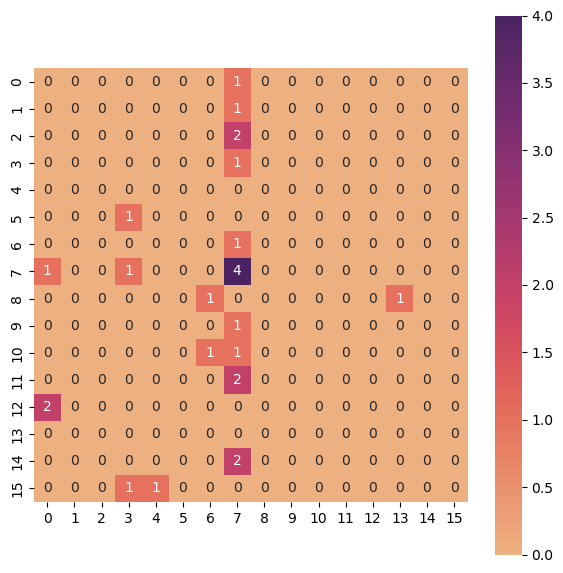

In [22]:
cm = cfm(y_test, y_pred)
plt.figure(figsize=(7,7))
sns.heatmap(cm, square=True, annot=True, fmt = 'd', cmap = 'flare')

# TF-IDF & Naive Bayes

In [23]:
fics = scraped.sample(frac=1).reset_index(drop=True)

In [37]:
fics_test = fics.iloc[:20]
fics_train = fics.iloc[20:]
y_train = fics_train['L1']
fics_train = fics_train.drop(columns=['L1'])
y_test = fics_test['L1']
fics_test = fics_test.drop(columns=['L1'])

In [38]:
tfvr = tfv(max_features=2000, stop_words=None)
X_train_tf = tfvr.fit_transform(fics_train['work'])
X_test_tf = tfvr.fit(fics_test['work'])

In [28]:
X_train_tf

<110x2000 sparse matrix of type '<class 'numpy.float64'>'
	with 73456 stored elements in Compressed Sparse Row format>

In [39]:
mn = mnb()
mn.fit(X_train_tf, y_train)

MultinomialNB()

In [47]:
print(tfvr.get_feature_names(), tfvr.idf_)

AttributeError: 'TfidfVectorizer' object has no attribute 'get_feature_names'

In [40]:
y_pred = mn.predict(X_test_tf)

ValueError: Expected 2D array, got scalar array instead:
array=TfidfVectorizer(max_features=2000).
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [32]:
cm = cfm(y_test, y_pred)
plt.figure(figsize=(7,7))
sns.heatmap(cm, square=True, annot=True, fmt = 'd', cmap = 'flare')

ValueError: Found input variables with inconsistent numbers of samples: [20, 26]

In [48]:
scraped['fd'] = scraped.bigrams.map(lambda x : nltk.FreqDist(x))
scraped['cfd'] = scraped.bigrams.map(lambda x : nltk.ConditionalFreqDist(x))

In [ ]:
df = [scraped[['L1', 'bigrams', 'fd', 'cfd', 'avg_kb']] for x in scraped.groupby(scraped['L1'])]

ValueError: Must pass 2-d input. shape=(31, 130, 5)

In [59]:
df

[           L1                                            bigrams  \
 0    MANDARIN  [(Kevin, sighed), (sighed, for), (for, the), (...   
 1      FRENCH  [(Clay, laid), (laid, on), (on, top), (top, of...   
 2      POLISH  [(Stiles, Stilinski), (Stilinski, is), (is, an...   
 7      ARABIC  [(``, Don), (Don, ’), (’, t), (t, panic), (pan...   
 15     KOREAN  [(Chapter, 1), (1, :), (:, Welcome), (Welcome,...   
 ..        ...                                                ...   
 373     IRISH  [(It, was), (was, a), (a, relief), (relief, to...   
 374     WELSH  [(Patsy, and), (and, Delia), (Delia, paused), ...   
 377   CHINESE  [(``, You), (You, know), (know, ,), (,, you), ...   
 379    FRENCH  [(Chapter, 1), (1, :), (:, Does), (Does, it), ...   
 380    GERMAN  [(Chapter, 1), (1, :), (:, A), (A, Study), (St...   
 
                                                     fd  \
 0    {('Kevin', 'sighed'): 2, ('sighed', 'for'): 1,...   
 1    {('Clay', 'laid'): 1, ('laid', 'on'): 1, ('on'